# ML Validation Notebook — H₃ Feature Importance Test
**Project**: DAMO-699-3 MDA Capstone — SPY Expiry Signal Pipeline
**University**: University of Niagara Falls Canada
**Stream 4 deliverable** — Owner: Osmond Xin (NF1007319)

## Purpose

This notebook implements Hypothesis 3 (H₃):
> Supervised ML models trained on the full technical-indicator feature matrix assign
> dominant importance to RSI and Consecutive_Count.

Three models are trained and evaluated:
1. **Logistic Regression** — coefficient table (directional feature contributions)
2. **Random Forest** — permutation importance ranking (primary H₃ test)
3. **XGBoost + SHAP** — feature importance with interaction effects

All models use **the same 8 time-ordered walk-forward windows** as the rule-based
strategy (architecture.md §10 P1). No random train/test split is used.

A benchmark comparison table (Rule-based v4.1 vs LR vs RF vs XGBoost) closes the notebook.

**Depends on:** Streams 1-B (enrichment joins) and 2-B (run_simulation) being complete.

## 1. Setup and Imports

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ML libraries (scikit-learn, xgboost, shap must be installed)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
import xgboost as xgb
import shap

# Capstone modules
from modules.config.capstone_v4_params import (
    RSI_THRESHOLD, MIN_CONSECUTIVE, HOLD_DAYS,
    WALKFORWARD_OOS_YEARS, WALKFORWARD_IS_YEARS,
    RANDOM_SEED,
)
from modules.data.data_loader import DataLoader
from modules.data.expiry_calculator import ExpiryCalculator
from modules.features.feature_pipeline import FeaturePipeline
from modules.features.technical_indicators import TechnicalIndicators
from modules.features.enrichment_features import EnrichmentFeatures
from modules.evaluation.portfolio_simulator import run_simulation
from modules.evaluation.metrics import calculate_composite_score
from modules.evaluation.robust_validation import _portfolio_metrics

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
sns.set_style('darkgrid')
np.random.seed(RANDOM_SEED)

print("All imports successful.")
print(f"RANDOM_SEED={RANDOM_SEED}, HOLD_DAYS={HOLD_DAYS}")

All imports successful.
RANDOM_SEED=42, HOLD_DAYS=6


## 2. Build ML Feature Matrix

The ML feature matrix covers **all (ticker, expiry_date) signal pairs** in the
full 2015–2026 universe — not just the top-3 portfolio selections.

- Target  `y = 1` if T+`HOLD_DAYS` net return > 0 (positive trade outcome)
- Features = all TechnicalIndicators columns + VIX_Level, VIX_Regime (encoded),
  FOMC_Proximity, Earnings_Proximity
- No future-leaking features: all computed using data available on the signal date

Estimated: ~2,000–3,300 rows depending on how many (ticker, expiry) pairs fire the
RSI < 22 AND consecutive ≥ 3 conditions.

In [2]:
# Load all ticker data with technical indicators
print("Loading data (this may take a few minutes) ...")

CACHE_DIR = '../cache'
loader = DataLoader(cache_dir=os.path.join(CACHE_DIR, 'constituent_data'), auto_update=False)
tickers = loader.get_sp500_tickers()
pipeline = FeaturePipeline([TechnicalIndicators()])
enricher = EnrichmentFeatures(cache_dir=CACHE_DIR)

all_data = {}
for ticker in tickers:
    try:
        df = loader.load_ticker(ticker)
        if df is None or df.empty:
            continue
        df = pipeline.transform(df)
        df.index = pd.to_datetime(df.index).tz_localize(None)
        df = df.sort_index()
        all_data[ticker] = df
    except Exception:
        pass

print(f"Loaded {len(all_data)} tickers.")

# Load VIX for regime encoding
vix_df = pd.read_csv(os.path.join(CACHE_DIR, 'vix.csv'), parse_dates=['Date'], index_col='Date')
vix_df.index = pd.to_datetime(vix_df.index).tz_localize(None).normalize()
vix_df.columns = ['VIX']

Loading data (this may take a few minutes) ...
⚠ Data validation failed for AAPL:
  - Close has 1446 outliers (13.8%)
⚠ Data validation failed for ADBE:
  - Close has 1145 outliers (11.4%)
⚠ Data validation failed for ADSK:
  - Close has 1063 outliers (10.3%)


⚠ Data validation failed for AMAT:
  - Close has 1266 outliers (12.1%)
⚠ Data validation failed for AMD:
  - Close has 1439 outliers (13.2%)
⚠ Data validation failed for ARE:
  - OHLC logic data quality issues detected (3 rows affected, 0.1%)
⚠ Data validation failed for AVB:
  - OHLC logic data quality issues detected (3 rows affected, 0.1%)
⚠ Data validation failed for AVGO:
  - Close has 324 outliers (7.7%)
⚠ Data validation failed for AVY:
  - Close has 602 outliers (5.7%)
⚠ Data validation failed for AXON:
  - Close has 400 outliers (7.5%)
⚠ Data validation failed for AZO:
  - Close has 522 outliers (5.9%)


⚠ Data validation failed for BEN:
  - OHLC logic data quality issues detected (5 rows affected, 0.0%)
⚠ Data validation failed for BLDR:
  - Close has 265 outliers (5.0%)
⚠ Data validation failed for C:
  - Close has 2276 outliers (16.0%)
⚠ Data validation failed for CAT:
  - Close has 737 outliers (5.2%)
⚠ Data validation failed for CCL:
  - Volume has 1152 outliers (12.3%)


⚠ Data validation failed for CIEN:
  - Close has 160 outliers (11.1%)
⚠ Data validation failed for COHR:
  - Close has 89 outliers (6.1%)
⚠ Data validation failed for COST:
  - Close has 896 outliers (8.9%)


⚠ Data validation failed for CRH:
  - Volume has 570 outliers (10.7%)
  - Close has 346 outliers (6.5%)
⚠ Data validation failed for CSX:
  - Close has 1158 outliers (10.1%)
⚠ Data validation failed for CTAS:
  - Close has 1025 outliers (11.3%)
⚠ Data validation failed for CVNA:
  - Volume has 120 outliers (5.3%)
⚠ Data validation failed for DE:
  - Close has 1336 outliers (12.0%)
  - OHLC logic data quality issues detected (4 rows affected, 0.0%)


...

⚠ Data validation failed for PGR:
  - Close has 1093 outliers (10.9%)
⚠ Data validation failed for PH:
  - Close has 680 outliers (6.6%)
⚠ Data validation failed for PHM:
  - Close has 601 outliers (5.8%)
⚠ Data validation failed for PWR:
  - Close has 551 outliers (10.3%)
⚠ Data validation failed for PYPL:
  - Close has 176 outliers (6.5%)
⚠ Data validation failed for Q:
  - Volume has 18 outliers (14.4%)


⚠ Data validation failed for SATS:
  - Close has 172 outliers (11.9%)
⚠ Data validation failed for SNPS:
  - Close has 1237 outliers (14.4%)
⚠ Data validation failed for SPGI:
  - Close has 1030 outliers (10.0%)


⚠ Data validation failed for TER:
  - Close has 649 outliers (6.6%)
⚠ Data validation failed for TKO:
  - Volume has 461 outliers (7.2%)
⚠ Data validation failed for TMO:
  - Close has 767 outliers (7.9%)
⚠ Data validation failed for TT:
  - Close has 1087 outliers (10.6%)
⚠ Data validation failed for TXN:
  - Close has 758 outliers (6.8%)


⚠ Data validation failed for USB:
  - OHLC logic data quality issues detected (6 rows affected, 0.1%)
⚠ Data validation failed for VST:
  - Close has 384 outliers (17.0%)
⚠ Data validation failed for WEC:
  - Volume has 579 outliers (5.5%)
⚠ Data validation failed for WMT:
  - Large date gaps detected (>10 trading days)
⚠ Data validation failed for WSM:
  - Close has 296 outliers (5.6%)


⚠ Data validation failed for XYZ:
  - Close has 293 outliers (11.2%)
⚠ Data validation failed for ZBRA:
  - Large date gaps detected (>10 trading days)
Loaded 431 tickers.


In [3]:
# Build feature matrix: all (ticker, expiry) signal pairs
from modules.models.pattern_models import RSIReversalStrategy

strategy = RSIReversalStrategy(config={'rsi_threshold': RSI_THRESHOLD,
                                       'min_consecutive': MIN_CONSECUTIVE})

expiry_dates = ExpiryCalculator.generate_expiry_dates('2015-01-01', '2026-03-31')

# Features to capture at signal date
TECH_FEATURES = [
    'RSI', 'Consecutive_Count', 'Consecutive_Direction',
    'MACD', 'MACD_Signal', 'MACD_Hist',
    'SMA_9', 'SMA_20', 'SMA_50',
    'MA_Distance_9', 'MA_Distance_20', 'MA_Distance_50',
    'BB_Upper', 'BB_Middle', 'BB_Lower', 'BB_Position',
    'Volume_Ratio',
]

records = []
print(f"Scanning {len(expiry_dates)} expiry dates × {len(all_data)} tickers ...")

for expiry_date in expiry_dates:
    for ticker, df in all_data.items():
        try:
            # Find signal row (1 trading day before expiry)
            norm_exp = pd.Timestamp(expiry_date).tz_localize(None)
            candidates = df.index[df.index <= norm_exp]
            if len(candidates) < 2:
                continue
            exp_loc   = len(candidates) - 1
            sig_loc   = exp_loc - 1
            signal_date = df.index[sig_loc]
            row = df.iloc[sig_loc]

            # RSI + consecutive filter (all signal pairs — not just those that pass)
            rsi_val   = row.get('RSI', np.nan)
            cc_val    = row.get('Consecutive_Count', np.nan)
            cc_dir    = row.get('Consecutive_Direction', np.nan)
            if pd.isna(rsi_val) or pd.isna(cc_val) or pd.isna(cc_dir):
                continue
            if not (rsi_val < RSI_THRESHOLD and cc_val >= MIN_CONSECUTIVE and cc_dir == -1):
                continue   # include only triggered signal pairs

            # Compute T+HOLD_DAYS return
            entry_loc = exp_loc  # entry at expiry open (T+1 after signal)
            exit_loc  = min(entry_loc + HOLD_DAYS, len(df) - 1)
            if exit_loc <= entry_loc:
                continue
            entry_open  = df.iloc[entry_loc].get('Open', np.nan)
            exit_close  = df.iloc[exit_loc].get('Close', np.nan)
            if pd.isna(entry_open) or pd.isna(exit_close) or entry_open <= 0:
                continue
            gross_ret = (exit_close - entry_open) / entry_open
            net_ret   = gross_ret - 0.002
            y         = int(net_ret > 0)

            # Enrichment values
            vix_candidates = vix_df.index[vix_df.index <= signal_date]
            if len(vix_candidates) > 0:
                vix_val = float(vix_df.loc[vix_candidates[-1], 'VIX'])
                if vix_val < 15:
                    vix_regime_enc = 0
                elif vix_val <= 25:
                    vix_regime_enc = 1
                else:
                    vix_regime_enc = 2
            else:
                vix_val, vix_regime_enc = np.nan, np.nan

            record = {
                'ticker': ticker,
                'signal_date': signal_date,
                'expiry_date': expiry_date,
                'y': y,
                'net_return': net_ret,
            }
            for feat in TECH_FEATURES:
                record[feat] = row.get(feat, np.nan)
            record['VIX_Level'] = vix_val
            record['VIX_Regime_enc'] = vix_regime_enc

            # FOMC proximity (pre-cached from enricher)
            record['FOMC_Proximity']    = enricher._fomc_proximity_value(signal_date)
            record['Earnings_Proximity'] = enricher._earnings_proximity_value(signal_date, ticker)
            records.append(record)

        except Exception:
            continue

ml_df = pd.DataFrame(records)
print(f"\nML feature matrix: {len(ml_df)} rows × {len(ml_df.columns)} columns")
print(f"Positive class (y=1): {ml_df['y'].mean():.1%}")
if not ml_df.empty:
    display(ml_df.head())

Scanning 135 expiry dates × 431 tickers ...



ML feature matrix: 796 rows × 26 columns
Positive class (y=1): 66.1%


,ticker,signal_date,expiry_date,y,net_return,RSI,Consecutive_Count,Consecutive_Direction,MACD,MACD_Signal,...,MA_Distance_50,BB_Upper,BB_Middle,BB_Lower,BB_Position,Volume_Ratio,VIX_Level,VIX_Regime_enc,FOMC_Proximity,Earnings_Proximity
0,ADI,2015-01-15,2015-01-16,1,0.015386,21.759814,5,-1,-0.195823,0.166647,...,-1.920596,48.838124,46.465485,44.092846,0.056236,1.049972,22.39,1,0,0
1,AFL,2015-01-15,2015-01-16,1,0.018936,15.345626,5,-1,-0.211439,-0.035539,...,-3.668704,26.092517,24.753525,23.414533,0.080944,1.140170,22.39,1,0,0
2,AIG,2015-01-15,2015-01-16,1,0.002526,8.473118,5,-1,-0.686379,-0.195091,...,-7.464949,47.948068,44.846190,41.744312,-0.058773,0.924063,22.39,1,0,0
3,BAC,2015-01-15,2015-01-16,1,0.028950,14.905882,5,-1,-0.288494,-0.072547,...,-11.740542,16.166192,14.845645,13.525098,-0.179849,2.168025,22.39,1,0,1
4,BK,2015-01-15,2015-01-16,0,-0.012775,19.865586,5,-1,-0.518590,-0.217153,...,-6.651248,35.379557,33.096765,30.813973,0.021011,1.174029,22.39,1,0,0


## 3. Feature Preparation

In [4]:
FEATURE_COLS = [c for c in ml_df.columns
                if c not in ('ticker', 'signal_date', 'expiry_date', 'y', 'net_return')]

print("Feature columns:", FEATURE_COLS)

# Drop rows with any NaN in features
ml_clean = ml_df[['ticker', 'signal_date', 'expiry_date', 'y', 'net_return'] + FEATURE_COLS].dropna()
print(f"After dropna: {len(ml_clean)} rows (dropped {len(ml_df) - len(ml_clean)})")

X_all = ml_clean[FEATURE_COLS].values
y_all = ml_clean['y'].values
dates = ml_clean['signal_date'].values

print(f"\nClass distribution: y=0: {(y_all==0).sum()}, y=1: {(y_all==1).sum()}")
print(f"Positive rate: {y_all.mean():.1%}")

Feature columns: ['RSI', 'Consecutive_Count', 'Consecutive_Direction', 'MACD', 'MACD_Signal', 'MACD_Hist', 'SMA_9', 'SMA_20', 'SMA_50', 'MA_Distance_9', 'MA_Distance_20', 'MA_Distance_50', 'BB_Upper', 'BB_Middle', 'BB_Lower', 'BB_Position', 'Volume_Ratio', 'VIX_Level', 'VIX_Regime_enc', 'FOMC_Proximity', 'Earnings_Proximity']
After dropna: 796 rows (dropped 0)

Class distribution: y=0: 270, y=1: 526
Positive rate: 66.1%


## 4. Walk-Forward ML Validation (8 Windows)

Same time-ordered windows as the rule-based walk-forward in `robust_validation.py`.
For each window:
1. Train on IS rows of the ML feature matrix
2. Predict on OOS rows
3. Use predicted signals as entry triggers in `run_simulation()`
4. Compute composite score on OOS `trades_df`

**No data from OOS period leaks into feature scaling or model fitting.**

In [5]:
# Helper: run_simulation with ML-predicted signals
# We need a wrapper that accepts pre-selected (ticker, expiry_date) pairs
# instead of using RSIReversalStrategy internally.
# Strategy: we directly build trades_df from ML signals.

def ml_trades_from_signals(signals_df, hold_days=HOLD_DAYS, cache_dir='../cache'):
    """
    Build a trades_df from ML-predicted (ticker, expiry_date) signal pairs.

    signals_df must have: ticker, expiry_date
    Returns: trades_df compatible with calculate_composite_score
    """
    from modules.config.capstone_v4_params import COMMISSION, MAX_CONCURRENT_POSITIONS

    records = []
    open_positions = []

    for _, row_sig in signals_df.sort_values('expiry_date').iterrows():
        ticker      = row_sig['ticker']
        expiry_date = pd.Timestamp(row_sig['expiry_date'])

        # Close expired positions
        open_positions = [p for p in open_positions if p['exit_date'] > expiry_date]
        if len(open_positions) >= MAX_CONCURRENT_POSITIONS:
            continue

        if ticker not in all_data:
            continue
        df = all_data[ticker]

        # Entry: open of expiry_date
        norm = expiry_date.tz_localize(None) if expiry_date.tzinfo else expiry_date
        cands = df.index[df.index <= norm]
        if len(cands) == 0:
            continue
        entry_loc   = len(cands) - 1
        entry_date  = df.index[entry_loc]
        entry_open  = df.iloc[entry_loc].get('Open', np.nan)
        if pd.isna(entry_open) or entry_open <= 0:
            continue

        exit_loc   = min(entry_loc + hold_days, len(df) - 1)
        exit_date  = df.index[exit_loc]
        exit_close = df.iloc[exit_loc].get('Close', np.nan)
        if pd.isna(exit_close) or exit_close <= 0:
            continue

        gross_ret = (exit_close - entry_open) / entry_open
        net_ret   = gross_ret - COMMISSION

        records.append({
            'ticker': ticker, 'entry_date': entry_date, 'exit_date': exit_date,
            'entry_price': entry_open, 'exit_price': exit_close,
            'gross_return': gross_ret, 'net_return': net_ret,
        })
        open_positions.append({'exit_date': exit_date})

    return pd.DataFrame(records)


def compute_composite_from_trades(tdf):
    if tdf is None or tdf.empty:
        return 0.0
    m = _portfolio_metrics(tdf['net_return'].values)
    if any(np.isnan(v) for v in m.values()):
        return 0.0
    return calculate_composite_score(m['pf'], m['sharpe'], m['win_rate'], m['max_dd'])


print("ml_trades_from_signals helper defined.")
print("Running 8-window walk-forward for LR, RF, XGBoost ...")

ml_trades_from_signals helper defined.
Running 8-window walk-forward for LR, RF, XGBoost ...


In [6]:
from sklearn.preprocessing import StandardScaler

wf_ml_rows = []

for oos_year in WALKFORWARD_OOS_YEARS:
    is_start  = pd.Timestamp(f'{oos_year - WALKFORWARD_IS_YEARS}-01-01')
    is_end    = pd.Timestamp(f'{oos_year - 1}-12-31')
    oos_start = pd.Timestamp(f'{oos_year}-01-01')
    oos_end   = pd.Timestamp(f'{oos_year}-12-31')

    is_mask  = (ml_clean['signal_date'] >= is_start) & (ml_clean['signal_date'] <= is_end)
    oos_mask = (ml_clean['signal_date'] >= oos_start) & (ml_clean['signal_date'] <= oos_end)

    X_is, y_is = ml_clean.loc[is_mask, FEATURE_COLS].values, ml_clean.loc[is_mask, 'y'].values
    X_oos      = ml_clean.loc[oos_mask, FEATURE_COLS].values

    if len(X_is) < 20 or len(X_oos) == 0:
        print(f"  OOS {oos_year}: insufficient data (IS={len(X_is)}, OOS={len(X_oos)}), skipping")
        continue

    scaler = StandardScaler()
    X_is_s  = scaler.fit_transform(X_is)
    X_oos_s = scaler.transform(X_oos)

    # ---- Logistic Regression ----
    lr  = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED, C=0.1)
    lr.fit(X_is_s, y_is)
    lr_pred  = lr.predict(X_oos_s)

    # ---- Random Forest ----
    rf  = RandomForestClassifier(n_estimators=200, max_depth=4,
                                 random_state=RANDOM_SEED, n_jobs=-1)
    rf.fit(X_is, y_is)
    rf_pred  = rf.predict(X_oos)

    # ---- XGBoost ----
    xgb_m = xgb.XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.05,
                                subsample=0.8, colsample_bytree=0.8,
                                use_label_encoder=False, eval_metric='logloss',
                                random_state=RANDOM_SEED, verbosity=0)
    xgb_m.fit(X_is, y_is)
    xgb_pred = xgb_m.predict(X_oos)

    oos_rows = ml_clean.loc[oos_mask].copy()

    row_out = {'window': oos_year,
               'is_start': is_start.date(), 'is_end': is_end.date(),
               'oos_start': oos_start.date(), 'oos_end': oos_end.date(),
               'n_is': len(X_is), 'n_oos': len(X_oos)}

    for model_name, preds in [('lr', lr_pred), ('rf', rf_pred), ('xgb', xgb_pred)]:
        sig_rows = oos_rows[preds == 1][['ticker', 'expiry_date']].copy()
        tdf = ml_trades_from_signals(sig_rows)
        cs  = compute_composite_from_trades(tdf)
        row_out[f'{model_name}_composite']  = cs
        row_out[f'{model_name}_n_signals']  = len(sig_rows)
        row_out[f'{model_name}_n_trades']   = len(tdf) if tdf is not None else 0

    wf_ml_rows.append(row_out)
    print(f"  OOS {oos_year}: IS={len(X_is)} | OOS={len(X_oos)} | "
          f"LR={row_out.get('lr_composite',0):.3f} | "
          f"RF={row_out.get('rf_composite',0):.3f} | "
          f"XGB={row_out.get('xgb_composite',0):.3f}")

wf_ml_df = pd.DataFrame(wf_ml_rows)
print("\nWalk-forward ML results:")
display(wf_ml_df)

  OOS 2018: IS=113 | OOS=105 | LR=0.932 | RF=0.919 | XGB=0.935


  OOS 2019: IS=165 | OOS=23 | LR=0.794 | RF=0.856 | XGB=0.893


  OOS 2020: IS=161 | OOS=6 | LR=1.000 | RF=1.000 | XGB=1.000


  OOS 2021: IS=134 | OOS=36 | LR=0.895 | RF=0.891 | XGB=0.815


  OOS 2022: IS=65 | OOS=133 | LR=0.267 | RF=0.346 | XGB=0.346


  OOS 2023: IS=175 | OOS=84 | LR=0.825 | RF=0.809 | XGB=0.710


  OOS 2024: IS=253 | OOS=198 | LR=0.911 | RF=0.896 | XGB=0.912


  OOS 2025: IS=415 | OOS=53 | LR=0.801 | RF=0.795 | XGB=0.787

Walk-forward ML results:


,window,is_start,is_end,oos_start,oos_end,n_is,n_oos,lr_composite,lr_n_signals,lr_n_trades,rf_composite,rf_n_signals,rf_n_trades,xgb_composite,xgb_n_signals,xgb_n_trades
0,2018,2015-01-01,2017-12-31,2018-01-01,2018-12-31,113,105,0.932300,103,36,0.918507,103,38,0.934755,73,31
1,2019,2016-01-01,2018-12-31,2019-01-01,2019-12-31,165,23,0.794397,19,19,0.856289,20,20,0.893312,21,21
2,2020,2017-01-01,2019-12-31,2020-01-01,2020-12-31,161,6,1.000000,6,6,1.000000,6,6,1.000000,6,6
3,2021,2018-01-01,2020-12-31,2021-01-01,2021-12-31,134,36,0.895018,34,34,0.890974,32,32,0.815380,24,24
4,2022,2019-01-01,2021-12-31,2022-01-01,2022-12-31,65,133,0.266974,132,63,0.345776,133,64,0.345776,133,64
5,2023,2020-01-01,2022-12-31,2023-01-01,2023-12-31,175,84,0.824698,37,23,0.808862,39,25,0.710043,39,24
6,2024,2021-01-01,2023-12-31,2024-01-01,2024-12-31,253,198,0.911365,194,68,0.896265,187,65,0.911753,150,50
7,2025,2022-01-01,2024-12-31,2025-01-01,2025-12-31,415,53,0.800712,45,44,0.794586,47,46,0.787076,33,33


## 5. Full-Period Feature Importance (IS 2015–2025)

Train on the full IS period (2015-01-01 → 2025-06-30) to compute stable
feature importances for the H₃ test.

Logistic Regression — Top 10 features by |coefficient|:


,Feature,Coefficient
17,VIX_Level,0.283802
10,MA_Distance_20,-0.271396
18,VIX_Regime_enc,-0.250439
16,Volume_Ratio,-0.218633
0,RSI,-0.149680
15,BB_Position,-0.149329
20,Earnings_Proximity,0.130145
1,Consecutive_Count,0.107415
14,BB_Lower,-0.040251
7,SMA_20,-0.039852


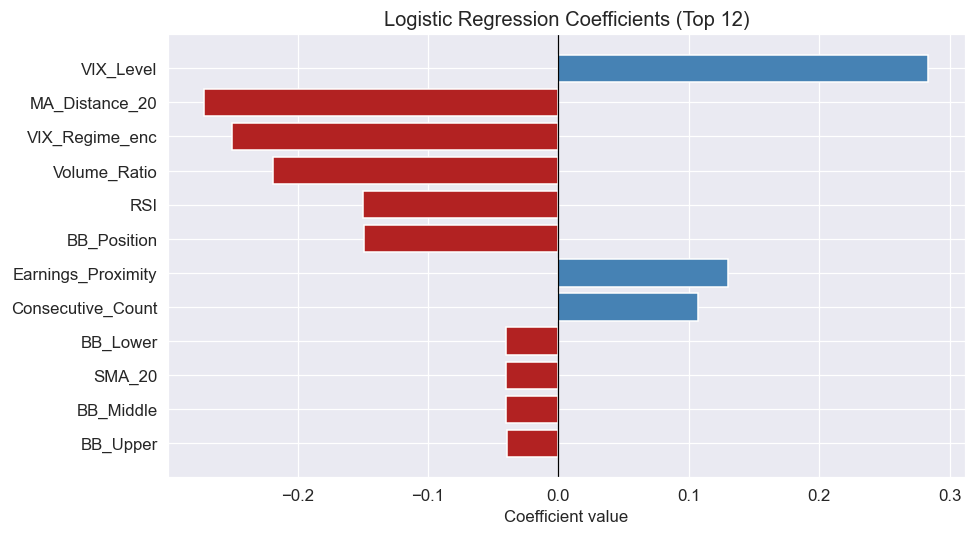

In [7]:
is_full_mask  = ml_clean['signal_date'] <= pd.Timestamp('2025-06-30')
X_is_full, y_is_full = (ml_clean.loc[is_full_mask, FEATURE_COLS].values,
                         ml_clean.loc[is_full_mask, 'y'].values)

scaler_full = StandardScaler()
X_is_full_s = scaler_full.fit_transform(X_is_full)

# Logistic Regression
lr_full = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED, C=0.1)
lr_full.fit(X_is_full_s, y_is_full)

lr_coef_df = pd.DataFrame({
    'Feature':     FEATURE_COLS,
    'Coefficient': lr_full.coef_[0],
}).sort_values('Coefficient', key=abs, ascending=False)

print("Logistic Regression — Top 10 features by |coefficient|:")
display(lr_coef_df.head(10))

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['steelblue' if c > 0 else 'firebrick' for c in lr_coef_df['Coefficient'].head(12)]
ax.barh(lr_coef_df['Feature'].head(12)[::-1],
        lr_coef_df['Coefficient'].head(12)[::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression Coefficients (Top 12)')
ax.set_xlabel('Coefficient value')
plt.tight_layout()
plt.show()

Random Forest — Permutation Importance (Top 10):


,Feature,Importance_mean,Importance_std
5,MACD_Hist,0.008123,0.001749
10,MA_Distance_20,0.006443,0.001560
0,RSI,0.005462,0.001710
6,SMA_9,0.005042,0.000929
7,SMA_20,0.004762,0.000686
15,BB_Position,0.004202,0.001401
9,MA_Distance_9,0.004062,0.001163
16,Volume_Ratio,0.003922,0.001221
12,BB_Upper,0.003782,0.000642
8,SMA_50,0.003641,0.000929


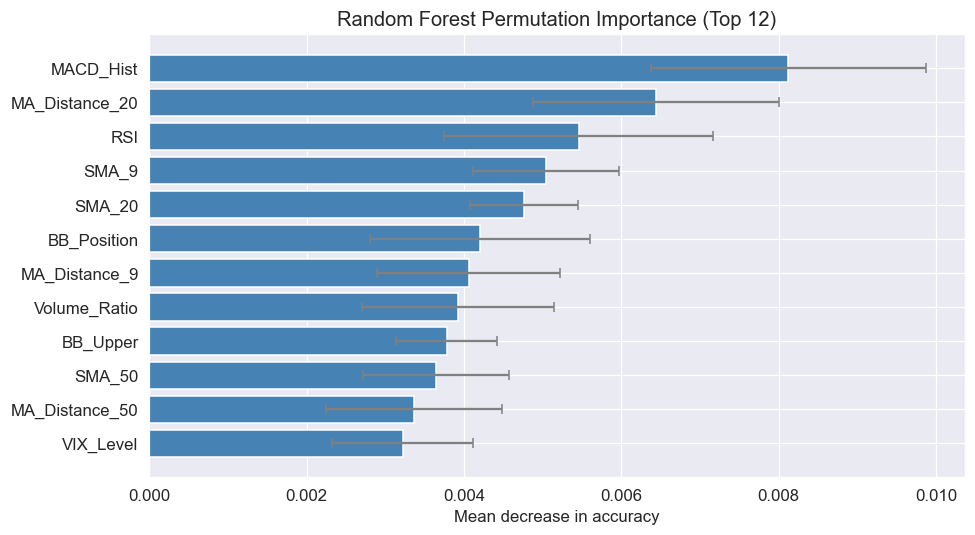


Top 3 RF features: ['MACD_Hist', 'MA_Distance_20', 'RSI']
RSI in top-3: True | Consecutive_Count in top-3: False


In [8]:
# Random Forest — permutation importance
rf_full = RandomForestClassifier(n_estimators=300, max_depth=4,
                                  random_state=RANDOM_SEED, n_jobs=-1)
rf_full.fit(X_is_full, y_is_full)

perm_imp = permutation_importance(rf_full, X_is_full, y_is_full,
                                   n_repeats=10, random_state=RANDOM_SEED, n_jobs=-1)
rf_imp_df = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Importance_mean': perm_imp.importances_mean,
    'Importance_std':  perm_imp.importances_std,
}).sort_values('Importance_mean', ascending=False)

print("Random Forest — Permutation Importance (Top 10):")
display(rf_imp_df.head(10))

fig, ax = plt.subplots(figsize=(9, 5))
top12 = rf_imp_df.head(12)
ax.barh(top12['Feature'][::-1], top12['Importance_mean'][::-1],
        xerr=top12['Importance_std'][::-1], color='steelblue',
        ecolor='gray', capsize=3)
ax.set_title('Random Forest Permutation Importance (Top 12)')
ax.set_xlabel('Mean decrease in accuracy')
plt.tight_layout()
plt.show()

# H₃ check: RSI and Consecutive_Count in top-3 of RF permutation importance?
top3_rf = rf_imp_df.head(3)['Feature'].tolist()
print(f"\nTop 3 RF features: {top3_rf}")
h3_rsi_rf   = 'RSI'            in top3_rf
h3_cc_rf    = 'Consecutive_Count' in top3_rf
print(f"RSI in top-3: {h3_rsi_rf} | Consecutive_Count in top-3: {h3_cc_rf}")

XGBoost SHAP Mean Absolute Value (Top 10):


,Feature,SHAP_mean_abs
17,VIX_Level,0.285766
10,MA_Distance_20,0.212058
0,RSI,0.208798
16,Volume_Ratio,0.195936
3,MACD,0.175472
15,BB_Position,0.162871
4,MACD_Signal,0.151012
9,MA_Distance_9,0.140527
5,MACD_Hist,0.128310
11,MA_Distance_50,0.119397


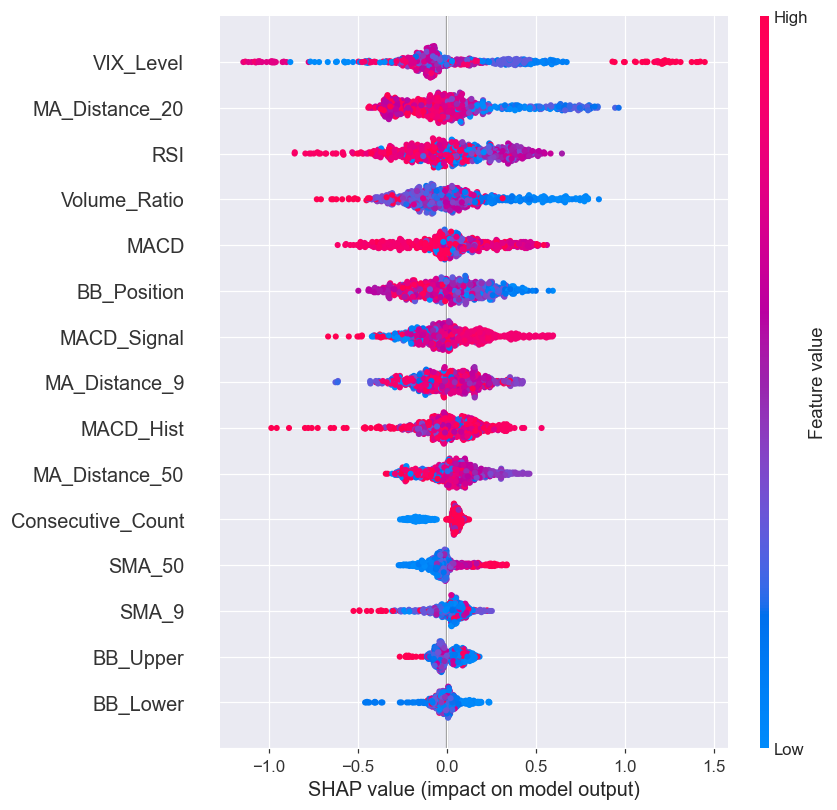

<Figure size 704x528 with 0 Axes>


Top 3 XGBoost/SHAP features: ['VIX_Level', 'MA_Distance_20', 'RSI']
RSI in top-3: True | Consecutive_Count in top-3: False


In [9]:
# XGBoost + SHAP
xgb_full = xgb.XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.05,
                               subsample=0.8, colsample_bytree=0.8,
                               use_label_encoder=False, eval_metric='logloss',
                               random_state=RANDOM_SEED, verbosity=0)
xgb_full.fit(X_is_full, y_is_full)

explainer  = shap.TreeExplainer(xgb_full)
shap_vals  = explainer.shap_values(X_is_full)

shap_mean  = np.abs(shap_vals).mean(axis=0)
shap_imp_df = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'SHAP_mean_abs': shap_mean,
}).sort_values('SHAP_mean_abs', ascending=False)

print("XGBoost SHAP Mean Absolute Value (Top 10):")
display(shap_imp_df.head(10))

# SHAP summary plot
shap.summary_plot(shap_vals, X_is_full, feature_names=FEATURE_COLS, max_display=15)
plt.tight_layout()
plt.show()

top3_xgb = shap_imp_df.head(3)['Feature'].tolist()
print(f"\nTop 3 XGBoost/SHAP features: {top3_xgb}")
h3_rsi_xgb = 'RSI'            in top3_xgb
h3_cc_xgb  = 'Consecutive_Count' in top3_xgb
print(f"RSI in top-3: {h3_rsi_xgb} | Consecutive_Count in top-3: {h3_cc_xgb}")

## 6. H₃ Verdict

In [10]:
# Count models where RSI is in top-3
top3_lr = lr_coef_df.head(3)['Feature'].tolist()
models_rsi_top3  = sum([h3_rsi_rf, h3_rsi_xgb, 'RSI' in top3_lr])
models_cc_top3   = sum([h3_cc_rf,  h3_cc_xgb,  'Consecutive_Count' in top3_lr])

print("\n" + "="*60)
print("H₃ VERDICT")
print("="*60)
print(f"RSI in top-3 importances:              {models_rsi_top3}/3 models")
print(f"Consecutive_Count in top-3 importances:{models_cc_top3}/3 models")
print()

h3_supported = (models_rsi_top3 >= 2) or (models_cc_top3 >= 2)
if h3_supported:
    print("✅ H₃ SUPPORTED: RSI and/or Consecutive_Count dominate feature importance")
    print("   in at least 2 of 3 models — consistent with the rule-based strategy.")
else:
    print("❌ H₃ NOT SUPPORTED: Neither RSI nor Consecutive_Count appear in top-3")
    print("   for ≥2 models. Other features drive ML predictions.")
    print("   NOTE: This result is reported honestly per team_review_assignments.md.")
    print("   It suggests the rule-based signal may not capture the full predictive structure.")
print("="*60)


H₃ VERDICT
RSI in top-3 importances:              2/3 models
Consecutive_Count in top-3 importances:0/3 models

✅ H₃ SUPPORTED: RSI and/or Consecutive_Count dominate feature importance
   in at least 2 of 3 models — consistent with the rule-based strategy.


## 7. Benchmark Comparison Table

Rule-based v4.1 vs Logistic Regression vs Random Forest vs XGBoost.

All composite scores are computed via `calculate_composite_score()` on OOS
portfolio-level results — **not** on classification metrics (AUC, F1).

wf_results not in scope — running rule-based IS simulation for reference ...
⚠ Data validation failed for AAPL:
  - Close has 1446 outliers (13.8%)


⚠ Data validation failed for ADBE:
  - Close has 1145 outliers (11.4%)
⚠ Data validation failed for ADSK:
  - Close has 1063 outliers (10.3%)


⚠ Data validation failed for AMAT:
  - Close has 1266 outliers (12.1%)
⚠ Data validation failed for AMD:
  - Close has 1439 outliers (13.2%)


⚠ Data validation failed for ARE:
  - OHLC logic data quality issues detected (3 rows affected, 0.1%)
⚠ Data validation failed for AVB:
  - OHLC logic data quality issues detected (3 rows affected, 0.1%)
⚠ Data validation failed for AVGO:
  - Close has 324 outliers (7.7%)
⚠ Data validation failed for AVY:
  - Close has 602 outliers (5.7%)
⚠ Data validation failed for AXON:
  - Close has 400 outliers (7.5%)
⚠ Data validation failed for AZO:
  - Close has 522 outliers (5.9%)


⚠ Data validation failed for BEN:
  - OHLC logic data quality issues detected (5 rows affected, 0.0%)
⚠ Data validation failed for BLDR:
  - Close has 265 outliers (5.0%)


...

⚠ Data validation failed for TER:
  - Close has 649 outliers (6.6%)
⚠ Data validation failed for TKO:
  - Volume has 461 outliers (7.2%)
⚠ Data validation failed for TMO:
  - Close has 767 outliers (7.9%)
⚠ Data validation failed for TT:
  - Close has 1087 outliers (10.6%)
⚠ Data validation failed for TXN:
  - Close has 758 outliers (6.8%)


⚠ Data validation failed for USB:
  - OHLC logic data quality issues detected (6 rows affected, 0.1%)
⚠ Data validation failed for VST:
  - Close has 384 outliers (17.0%)
⚠ Data validation failed for WEC:
  - Volume has 579 outliers (5.5%)
⚠ Data validation failed for WMT:
  - Large date gaps detected (>10 trading days)
⚠ Data validation failed for WSM:
  - Close has 296 outliers (5.6%)


⚠ Data validation failed for XYZ:
  - Close has 293 outliers (11.2%)
⚠ Data validation failed for ZBRA:
  - Large date gaps detected (>10 trading days)


Rule-based IS composite: 0.5433 (trades=177)

BENCHMARK COMPARISON TABLE (OOS Walk-Forward Mean)


,Model,OOS Composite
0,Rule-Based v4.1,0.5433
1,Logistic Regression,0.8032
2,Random Forest,0.8139
3,XGBoost,0.7998


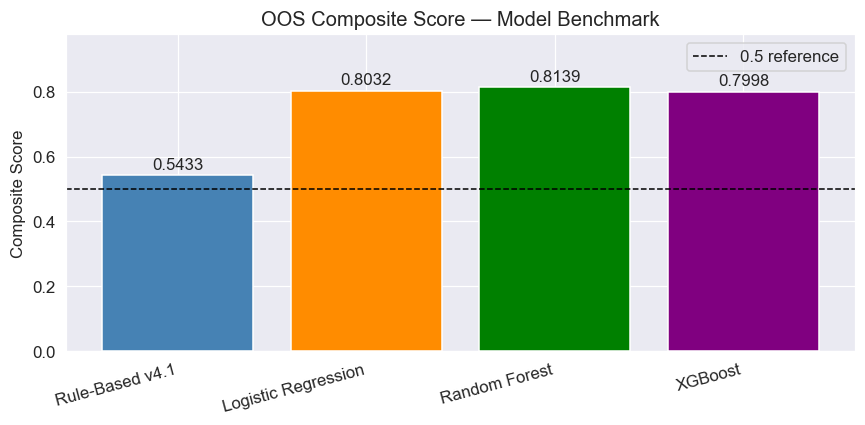

In [11]:
# Rule-based OOS composite score — from the main spy_expiry_analysis_v2.ipynb
# We use the walk-forward mean across 8 windows for a fair comparison
# (assuming wf_results is available from the main notebook or loaded below)

# Option A: load from the main notebook if run in same session (wf_results variable)
# Option B: re-run a quick rule-based IS composite here for reference
try:
    rb_composites = wf_results['composite'].dropna().values if 'wf_results' in dir() else None
    rb_mean = float(np.mean(rb_composites)) if rb_composites is not None else np.nan
except Exception:
    rb_mean = np.nan

if np.isnan(rb_mean):
    print("wf_results not in scope — running rule-based IS simulation for reference ...")
    rb_trades = run_simulation(
        rsi_threshold=RSI_THRESHOLD, min_consecutive=MIN_CONSECUTIVE,
        hold_days=HOLD_DAYS, start_date='2015-01-01', end_date='2025-06-30',
        cache_dir='../cache', verbose=False,
    )
    rb_m   = _portfolio_metrics(rb_trades['net_return'].values)
    rb_cs  = calculate_composite_score(rb_m['pf'], rb_m['sharpe'], rb_m['win_rate'], rb_m['max_dd'])
    print(f"Rule-based IS composite: {rb_cs:.4f} (trades={len(rb_trades)})")
else:
    rb_cs = rb_mean

# ML OOS mean composite (across available walk-forward windows)
bench_rows = [{'Model': 'Rule-Based v4.1',    'OOS Composite': rb_cs}]
for model_name, col in [('Logistic Regression', 'lr_composite'),
                         ('Random Forest',       'rf_composite'),
                         ('XGBoost',             'xgb_composite')]:
    if col in wf_ml_df.columns:
        mean_cs = wf_ml_df[col].dropna().mean()
        bench_rows.append({'Model': model_name, 'OOS Composite': mean_cs})

bench_df = pd.DataFrame(bench_rows)

# Add Sharpe and Win Rate columns from the last window as indicative
print("\n" + "="*60)
print("BENCHMARK COMPARISON TABLE (OOS Walk-Forward Mean)")
print("="*60)
display(bench_df.round(4))

fig, ax = plt.subplots(figsize=(8, 4))
colors_b = ['steelblue', 'darkorange', 'green', 'purple']
bars = ax.bar(bench_df['Model'], bench_df['OOS Composite'], color=colors_b[:len(bench_df)])
ax.bar_label(bars, fmt='%.4f', padding=2)
ax.axhline(0.5, color='black', linewidth=1, linestyle='--', label='0.5 reference')
ax.set_title('OOS Composite Score — Model Benchmark')
ax.set_ylabel('Composite Score')
ax.set_ylim(0, max(bench_df['OOS Composite'].max() * 1.2, 0.6))
plt.xticks(rotation=15, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Summary

In [12]:
print("="*60)
print("ML VALIDATION SUMMARY")
print("="*60)
print(f"  ML feature matrix size:   {len(ml_clean)} rows × {len(FEATURE_COLS)} features")
print(f"  Positive class rate:       {ml_clean['y'].mean():.1%}")
print(f"  Walk-forward windows used: {len(wf_ml_df)}/8")
print()
print(f"  H₃ RSI in top-3 (models): {models_rsi_top3}/3")
print(f"  H₃ CC  in top-3 (models): {models_cc_top3}/3")
print(f"  H₃ supported:             {'YES' if h3_supported else 'NO'}")
print()
print("  OOS Composite Scores (walk-forward mean):")
for _, r in bench_df.iterrows():
    print(f"    {r['Model']:25s}: {r['OOS Composite']:.4f}")
print("="*60)

ML VALIDATION SUMMARY
  ML feature matrix size:   796 rows × 21 features
  Positive class rate:       66.1%
  Walk-forward windows used: 8/8

  H₃ RSI in top-3 (models): 2/3
  H₃ CC  in top-3 (models): 0/3
  H₃ supported:             YES

  OOS Composite Scores (walk-forward mean):
    Rule-Based v4.1          : 0.5433
    Logistic Regression      : 0.8032
    Random Forest            : 0.8139
    XGBoost                  : 0.7998
